# 🌸  Iris Flower Classification using Machine Learning

**Submitted By:** Tarannum Mohammad Nadaf  
**Internship:** Oasis Infobyte  
**Track:** Data Science  
**Project:** Iris Flower Classification  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, Jupyter Notebook


## Import Libraries

In this step, we import all the required Python libraries.
These libraries help us load the dataset, visualize the data, train machine learning models, and evaluate their performance.

In [15]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

## Load Dataset
Load the Iris dataset from Scikit-learn.

In [16]:
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["Species"] = iris.target

df["Species"] = df["Species"].map({
    0:"Setosa",
    1:"Versicolor",
    2:"Virginica"
})

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  Species  
0  Setosa  
1  Setosa  
2  Setosa  
3  Setosa  
4  Setosa  


## Exploratory Data Analysis (EDA)

EDA helps us understand the dataset.
We check the dataset shape, column names, data types, missing values, and summary statistics.

In [17]:
print("Shape")
print(df.shape)

print("\nDataset Columns:")
print(df.columns)

print("\nData Types")
print(df.dtypes)

print("\nMissing Values")
print(df.isnull().sum())

print("\nStatistics")
print(df.describe())

Shape
(150, 5)

Dataset Columns:
Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'Species'],
      dtype='object')

Data Types
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
Species               object
dtype: object

Missing Values
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
Species              0
dtype: int64

Statistics
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.

## Pair Plot Visualization

The pair plot shows the relationship between all features.
Different colors represent different Iris flower species.


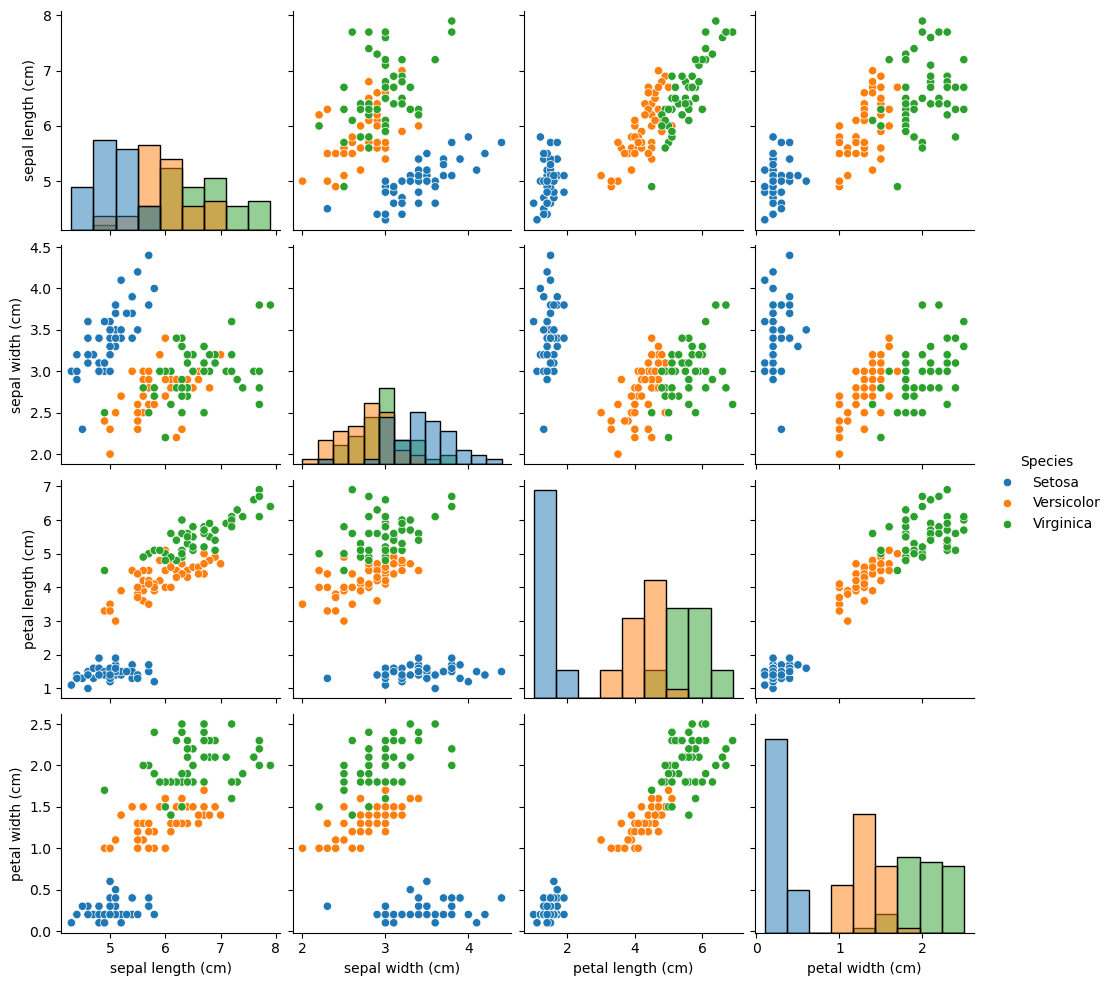

In [18]:
sns.pairplot(
    df,
    hue="Species",
    diag_kind="hist",
    height=2.5
)

plt.show()

## Box Plot Visualization

Box plots help us understand the distribution of each feature.
They also help identify possible outliers.

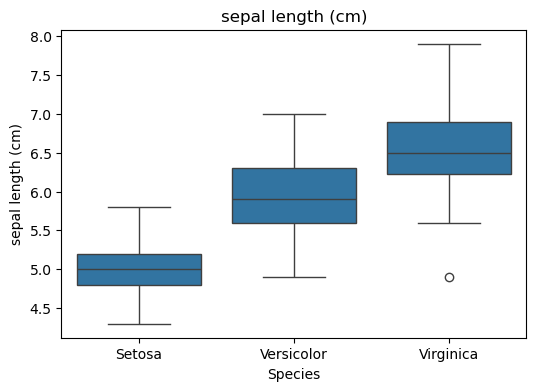

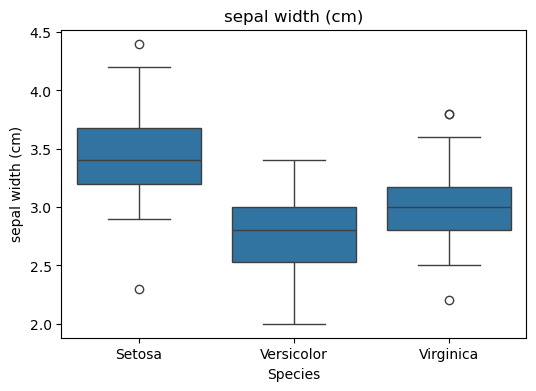

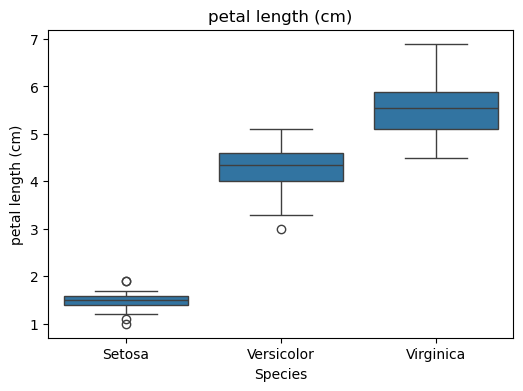

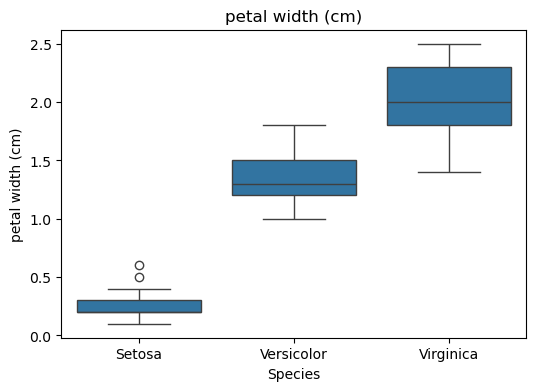

In [19]:
for col in df.columns[:-1]:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="Species",y=col,data=df)
    plt.title(col)
    plt.show()

## Feature Selection

The first four columns are used as input features.

Among them, **petal length** and **petal width** are the most important features because they clearly separate the three Iris flower species.

The target variable is **Species**.

## Feature Selection

The first four columns are selected as input features (X).
The Species column is selected as the target variable (y).

In [20]:
X = df.drop("Species", axis=1)
y = df["Species"]

## Split the Dataset

The dataset is divided into training and testing data.
80% of the data is used for training and 20% for testing.

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Verify Data
Check the shape of training and testing data.

In [22]:
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Labels Shape:", y_train.shape)
print("Testing Labels Shape:", y_test.shape)

Training Features Shape: (120, 4)
Testing Features Shape: (30, 4)
Training Labels Shape: (120,)
Testing Labels Shape: (30,)


## Logistic Regression Model

Logistic Regression is a supervised machine learning classification algorithm.
It is trained using the training dataset to classify Iris flower species.

In [23]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=200)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

## Evaluate Logistic Regression

The Logistic Regression model is evaluated using Accuracy, Confusion Matrix, and Classification Report.
These metrics measure the model's performance.

In [24]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

acc_lr = accuracy_score(y_test, pred_lr)

print("Logistic Regression Accuracy:", acc_lr)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, pred_lr))

print("\nClassification Report")
print(classification_report(y_test, pred_lr))

Logistic Regression Accuracy: 1.0

Confusion Matrix
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00         9
   Virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## K-Nearest Neighbors (KNN) Model

Train the K-Nearest Neighbors model.
It predicts the flower species based on the nearest training samples.

In [25]:
from sklearn.neighbors import KNeighborsClassifier

knn=KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train,y_train)

pred_knn=knn.predict(X_test)

## Evaluate KNN Model

Evaluate the KNN model.

In [26]:
acc_knn = accuracy_score(y_test, pred_knn)

print("KNN Accuracy:", acc_knn)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, pred_knn))

print("\nClassification Report")
print(classification_report(y_test, pred_knn))

KNN Accuracy: 1.0

Confusion Matrix
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00         9
   Virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Model Comparison

Compare the performance of both models.

In [27]:
print("Logistic Regression Accuracy:", acc_lr)
print("KNN Accuracy:", acc_knn)

if acc_lr > acc_knn:
    print("Best Model: Logistic Regression")
elif acc_knn > acc_lr:
    print("Best Model: KNN")
else:
    print("Both Models Perform Equally Well")

Logistic Regression Accuracy: 1.0
KNN Accuracy: 1.0
Both Models Perform Equally Well


## Prediction

Predict the species of a new flower.

In [28]:
sample = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=X.columns
)

prediction = knn.predict(sample)

print("Predicted Species:", prediction[0])

Predicted Species: Setosa


## Results

- Logistic Regression Accuracy: 100%
- KNN Accuracy: 100%
- Best Model: Both Models Perform Equally Well

## Conclusion

The Iris Flower Classification project was completed using Logistic Regression and KNN models.
Both models achieved 100% accuracy on the test dataset. 
The models successfully predicted the Iris flower species.